TIME SERIES SPLIT

Sono metodi di cross-validation basate sui fold dei dati soprattutto per dati che presentano sequenze temporali, ed è usato perchè k-fold queste relazioni non può coglierle.
Con i dati temporali hai ordine del tempo. Non si possono mescolare i dati
K-Fold è sbagliato perchè fa shuffle (mischia). Il rischio è di avere nel train un mese successivo al mese nel test (esempio train su aprile testo su gennaio). In questo caso è come se usassi il futuro per prevedere il passato. Questo fenomeno è detto leakage temporale.,
Time Serie Split divide i dati rispettando l'ordine temporale
Per far questo il train cresce nel tempo includendo tutti i train delle iterazioni precedenti.
Esempio
Vendite 2020, vendite 2021, vendite 2022, vendite 2023
train1: vendite 2020; test 2021
train2: vendite 2020, vendite 2021; test 2022
train3: vendite 2020, vendite 2021, vendite 2022; test 2023


nel databases di sklearn non sono presenti dataset con serie temporali, pertanto devo prendere i dati da altre parti

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,mean_squared_error, r2_score

In [24]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df = df.rename(columns={ 'Passengers': 'y' })
display(df)

,y
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


Esplorazione iniziale dei dati

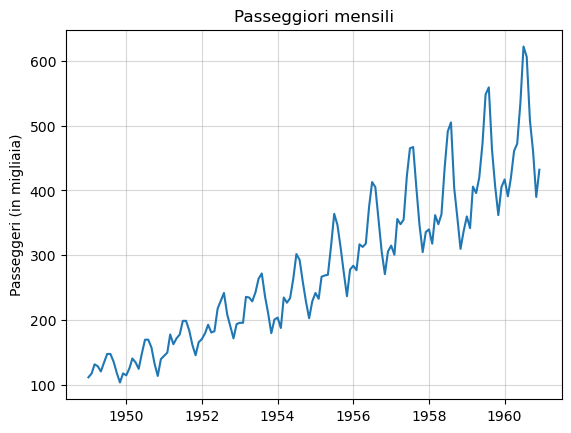

In [25]:
plt.Figure(figsize=(8,6))
plt.plot(df.index,df["y"])
plt.title("Passeggiori mensili")
plt.ylabel("Passeggeri (in migliaia)")
plt.grid(True,alpha=0.5)
plt.show()

Deve prevedere quanti passeggeri voleranno in un dato mese, è un problema di regressione lineare (y è numerico).
Ho due tipi di problemi:
1) il dataset ha solo una colonna di input (X) ed il target è un intero. La regressione linerare si applica a dati il cui target è continuo, in questo caso è un intero,
2) Il traffico aereo di un mese dipende dal mese precedente, dal traffico aereo del mese (utile confronto con stesso mese anno precedente).
Creiamo 3 colonne in più, con dati storici mensile ed annuali, 
1) rappresenta il numero di passeggeri nel mese precedente per catturare la sequenza temporale tra i mesi e la stagionalità
2) n. di passeggeri nello stesso mese ma dell'anno precedente. Serve per ricavare pattern di basse/medie/alte stagioni (esempio estate di tutti gli anni sono i mesi che si vola di più)
3) media degli ultimi 12 mesi questo per mostrare se il traffico aereo è cresciuto o diminuito nel tempo e fornisce al modello il contesto sul comportamento a lungo termine della serie

feature enginering

In [31]:
df_features=df.copy()
df_features['m_prev'] = df_features['y'].shift(1) # da i valori di y spostati di una riga indietro (mese precedente), server a cattura la dipendeza tra i mesi
df_features['a_prev'] = df_features['y'].shift(12) #n. di passeggeri stesso mese anno precedente
df_features['trend_year'] = df_features['y'].rolling(window=12).mean() #faccio una finestra mobile, prendo la media degli ultimi 12 mesi
#print(df_features)
df_features = df_features.dropna().copy() #elimino le righe con valori mancanti NaN
#con dropna elimino tutte le righe che hanno almeno una colonna NaN quindi anche righe le cui 3 colonne appena aggiunte(ne basta una) sono null

#print(df_features)
#print(df_features.columns)
X = df_features.drop(columns=['y'])
y=df_features["y"].values

display(X)

,m_prev,a_prev,trend_year
Month,,,
1950-01-01,118.0,112.0,126.916667
1950-02-01,115.0,118.0,127.583333
1950-03-01,126.0,132.0,128.333333
1950-04-01,141.0,129.0,128.833333
1950-05-01,135.0,121.0,129.166667
...,...,...,...
1960-08-01,622.0,559.0,463.333333
1960-09-01,606.0,463.0,467.083333
1960-10-01,508.0,407.0,471.583333


In [23]:
display(y)
display(len(y))

array([115, 126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140, 145,
       150, 178, 163, 172, 178, 199, 199, 184, 162, 146, 166, 171, 180,
       193, 181, 183, 218, 230, 242, 209, 191, 172, 194, 196, 196, 236,
       235, 229, 243, 264, 272, 237, 211, 180, 201, 204, 188, 235, 227,
       234, 264, 302, 293, 259, 229, 203, 229, 242, 233, 267, 269, 270,
       315, 364, 347, 312, 274, 237, 278, 284, 277, 317, 313, 318, 374,
       413, 405, 355, 306, 271, 306, 315, 301, 356, 348, 355, 422, 465,
       467, 404, 347, 305, 336, 340, 318, 362, 348, 363, 435, 491, 505,
       404, 359, 310, 337, 360, 342, 406, 396, 420, 472, 548, 559, 463,
       407, 362, 405, 417, 391, 419, 461, 472, 535, 622, 606, 508, 461,
       390, 432])

132

In [32]:
k=10

In [33]:
model=RandomForestRegressor(n_estimators=100,random_state=42)

K-Fold

In [36]:
accuracy_kf=[]

kf=KFold(n_splits=k,shuffle=True,random_state=42)

for train_index, test_index in kf.split(X):  #ritorna gli indici di come ha fatto lo split, indici di train e test
    #prendo il dataset originale e seleziono le righe corrispondenti agli indici
    X_train, X_test=X.iloc[train_index],X.iloc[test_index]
    y_train, y_test=y[train_index],y[test_index]
    #standarizzo le feature (da fare necessariamente dopo lo split)
    scaler=StandardScaler()
    X_train_scaled=scaler.fit_transform(X_train)
    X_test_scaled=scaler.transform(X_test)
    #alleno il modello
    model.fit(X_train_scaled,y_train)
    #predizioni
    y_pred=model.predict(X_test_scaled)
    #calcolo le metriche di predizione
    r2=r2_score(y_test,y_pred)
    #salvo le metriche
    accuracy_kf.append(r2)

Time Series Split

In [47]:
accuracy_ts=[]

tscv=TimeSeriesSplit(n_splits=k)

for train_index, test_index in tscv.split(X):  #ritorna gli indici di come ha fatto lo split, indici di train e test
    #prendo il dataset originale e seleziono le righe corrispondenti agli indici
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]
    #standarizzo le feature (da fare necessariamente dopo lo split)
    scaler=StandardScaler()
    X_train_scaled=scaler.fit_transform(X_train)
    X_test_scaled=scaler.transform(X_test)
    #alleno il modello
    model.fit(X_train_scaled,y_train)
    #predizioni
    y_pred=model.predict(X_test_scaled)
    #calcolo le metriche di predizione
    r2=r2_score(y_test,y_pred)
    #salvo le metriche
    accuracy_ts.append(r2)

Calcolo le medie

In [55]:
mean_std = np.mean(accuracy_kf)
std_std = np.std(accuracy_kf)
mean_ts = np.mean(accuracy_ts)
std_ts = np.std(accuracy_ts)

In [58]:
print(f"Standard K-Fold:\n\tMEAN:\t{mean_std:.4f}\n\tSTD :\t{std_std:.4f}\n\tR2:\n\t{np.round(accuracy_kf, 4)}")
print(f"Time Series Split:\n\tMEAN:\t{mean_ts:.4f}\n\tSTD :\t{std_ts:.4f}\n\tR2:\n\t{np.round(accuracy_ts, 4)}")

Standard K-Fold:
	MEAN:	0.9754
	STD :	0.0129
	R2:
	[0.9879 0.9924 0.9851 0.9567 0.953  0.9736 0.9628 0.9835 0.9816 0.9769]
Time Series Split:
	MEAN:	0.4286
	STD :	0.3885
	R2:
	[-0.5809  0.2307  0.5118  0.6178  0.1675  0.6352  0.6954  0.4991  0.6889
  0.8208]


plotto

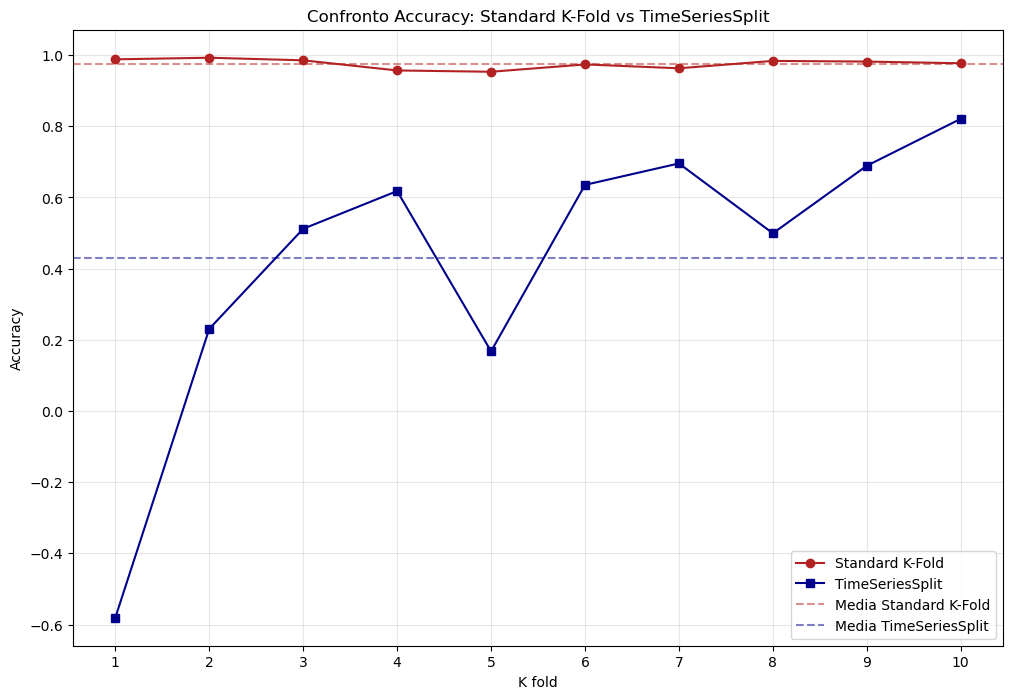

In [54]:
plt.figure(figsize=(12, 8))
plt.plot(range(1, k + 1), accuracy_kf, color='firebrick', marker='o', label="Standard K-Fold")
plt.plot(range(1, k + 1), accuracy_ts, color='darkblue', marker='s', label="TimeSeriesSplit")

plt.axhline(mean_std, color='firebrick', linestyle='--', alpha=0.5, label="Media Standard K-Fold")
plt.axhline(mean_ts,  color='darkblue', linestyle='--', alpha=0.5, label="Media TimeSeriesSplit")

plt.xticks(range(1, k + 1))

plt.xlabel("K fold")
plt.ylabel("Accuracy")
plt.title("Confronto Accuracy: Standard K-Fold vs TimeSeriesSplit")
plt.legend()
plt.grid(alpha=0.3)
plt.show()